# IBM HR Analytics Employee Attrition & Performance Analysis

In [2]:
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import pandas as pd

## Overview of the Dataset

In [3]:
data=pd.read_csv('/Users/kamyasindhu/Downloads/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
data.size

51450

In [8]:
data.shape

(1470, 35)

In [9]:
data.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Exploratory Data Analysis 

In [10]:
business_travel=data['BusinessTravel'].value_counts()

In [11]:
business_travel

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

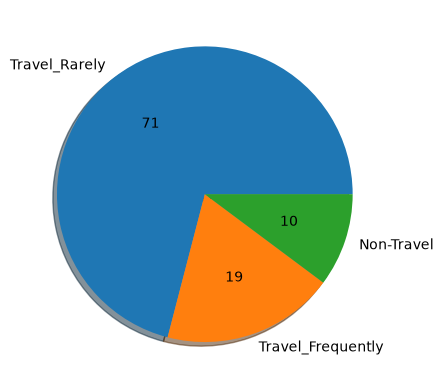

In [12]:
plt.pie(business_travel.values,labels=business_travel.index,autopct='%.f',shadow=True)
plt.show()

#### Around 71% employees travel rarely for business trips. Whereas only 19% are frequent travelers.

In [13]:
dept=data['Department'].value_counts()

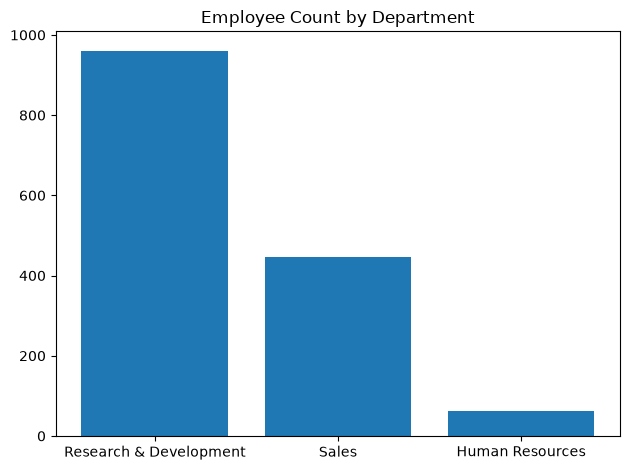

In [14]:
plt.bar(dept.index,dept.values)
plt.xlabel=('Department')
plt.ylabel=('Number of employees')
plt.title('Employee Count by Department')
plt.tight_layout()
plt.show()

#### The Research & Development department accounts for 65% of the total workforce of the company. HR department has the least contribution to workforce.

In [15]:
print(data.Age.max())

60


In [16]:
print(data.Age.min())

18


#### Youngest employee/s is/are 18 years old whereas the oldest employee/s is/are 60 years old.

#### Age distribution using a histogram.

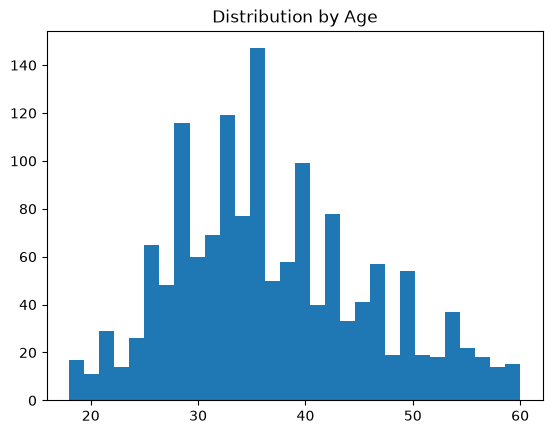

In [17]:
plt.hist(data.Age,bins=30)
plt.title('Distribution by Age')
plt.show()

#### Majority of the employees lie in the age group of 30-40 years old suggesting an experienced workforce with fewer younger employees.

In [18]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [19]:
grp=data.groupby(['Department','Attrition']).size().reset_index(name='Count')

In [20]:
grp

,Department,Attrition,Count
0,Human Resources,No,51
1,Human Resources,Yes,12
2,Research & Development,No,828
3,Research & Development,Yes,133
4,Sales,No,354
5,Sales,Yes,92


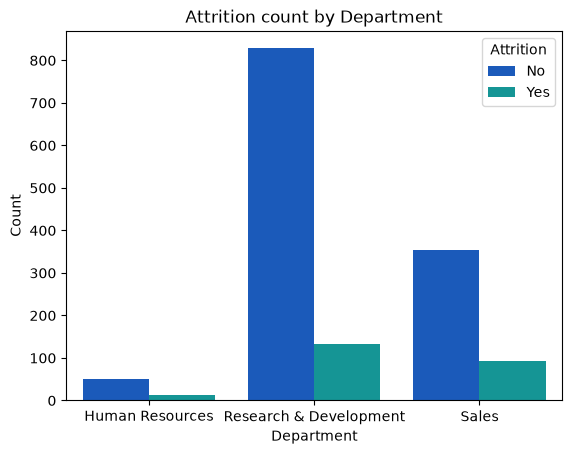

In [21]:
sb.barplot(data=grp,x='Department',y='Count',hue='Attrition',palette='winter')
plt.title('Attrition count by Department')
plt.show()

In [22]:
data['Age_groups']=pd.cut(data.Age,bins=[18,25,35,45,float('inf')],labels=['18-25','26-35','36-45','46-60'])

In [23]:
data['Age_groups']

0       36-45
1       46-60
2       36-45
3       26-35
4       26-35
        ...  
1465    36-45
1466    36-45
1467    26-35
1468    46-60
1469    26-35
Name: Age_groups, Length: 1470, dtype: category
Categories (4, str): ['18-25' < '26-35' < '36-45' < '46-60']

In [24]:
age_grp=data['Age_groups'].value_counts().sort_index()

In [25]:
age_grp

Age_groups
18-25    115
26-35    606
36-45    468
46-60    273
Name: count, dtype: int64

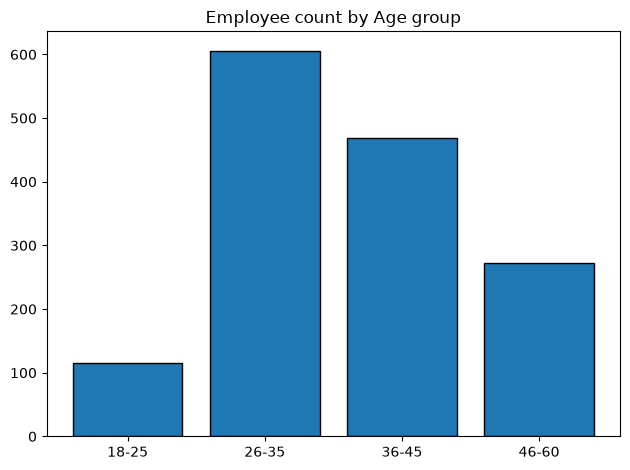

In [26]:
plt.bar(age_grp.index.astype(str),age_grp.values,edgecolor='black')
plt.title('Employee count by Age group')
plt.tight_layout()
plt.show()

In [27]:
data['JobSatisfaction'].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [28]:
grp_satisf=data.groupby(['Department','JobSatisfaction']).size()

In [29]:
grp_satisf

Department              JobSatisfaction
Human Resources         1                   11
                        2                   20
                        3                   15
                        4                   17
Research & Development  1                  192
                        2                  174
                        3                  300
                        4                  295
Sales                   1                   86
                        2                   86
                        3                  127
                        4                  147
dtype: int64

In [30]:
table=pd.crosstab(data['Department'],data['JobSatisfaction'],normalize='index')*100

In [31]:
table

JobSatisfaction,1,2,3,4
Department,,,,
Human Resources,17.460317,31.746032,23.809524,26.984127
Research & Development,19.979188,18.106139,31.217482,30.697190
Sales,19.282511,19.282511,28.475336,32.959641


In [32]:
percentages=table[4].round(1)

In [33]:
print(percentages)

Department
Human Resources           27.0
Research & Development    30.7
Sales                     33.0
Name: 4, dtype: float64


#### Sales department has the highest level of job satisfaction.

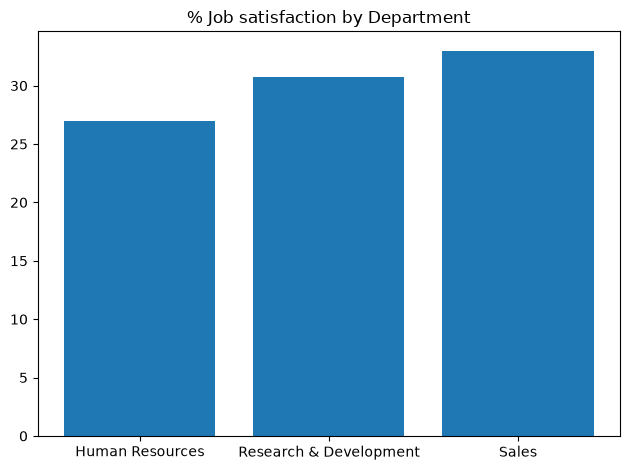

In [34]:
plt.bar(percentages.index,percentages.values)
plt.title('% Job satisfaction by Department')
plt.tight_layout()
plt.show()

In [35]:
data['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [36]:
print(data['YearsAtCompany'].mean().round(1))

7.0


#### Employees stay at the company for an average of 7 years suggesting a decent employee retention.

In [37]:
relation=pd.crosstab(data['Attrition'],data['JobSatisfaction'],normalize='index')*100

In [38]:
relation.round(2)

JobSatisfaction,1,2,3,4
Attrition,,,,
No,18.09,18.98,29.93,33.01
Yes,27.85,19.41,30.80,21.94


#### As job satisfaction increases, the attrition rate decreases. Employees with higher job satisfaction are less likely to leave the company.

In [39]:
data.filter(items=['Department','MonthlyIncome']).sample(10)

,Department,MonthlyIncome
1023,Research & Development,2066
117,Sales,9738
1128,Research & Development,5562
407,Research & Development,2654
309,Research & Development,4821
1225,Research & Development,16704
342,Research & Development,7143
485,Research & Development,2187
120,Research & Development,2613
1226,Research & Development,3433


#### Average monthly income by department.

In [40]:

grp_income=data.groupby('Department')['MonthlyIncome'].mean()

In [41]:
grp_income.round(2)

Department
Human Resources           6654.51
Research & Development    6281.25
Sales                     6959.17
Name: MonthlyIncome, dtype: float64

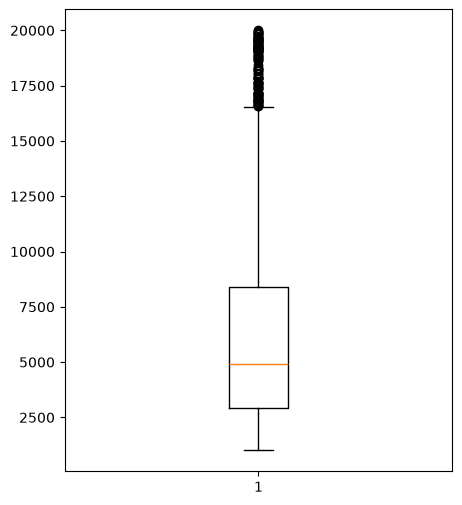

In [42]:
plt.figure(figsize=[5,6])
plt.boxplot(data['MonthlyIncome'])
plt.show()

In [43]:
grp_att=data.groupby('Attrition')['MonthlyIncome'].mean().round(2)

In [44]:
grp_att

Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64

#### Attrition - Income relationship

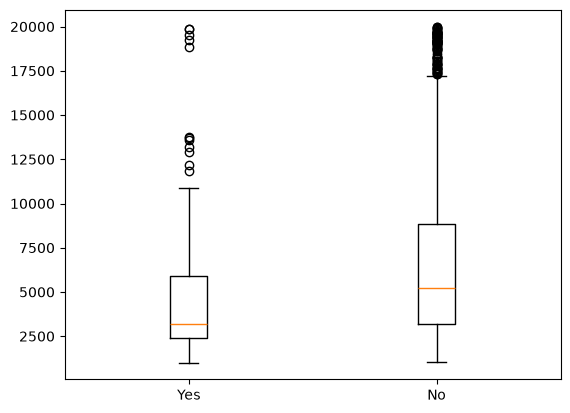

In [45]:

plotval=[data[data['Attrition']=='Yes']['MonthlyIncome'],data[data['Attrition']=='No']['MonthlyIncome']]
plt.boxplot(plotval,tick_labels=['Yes','No'])
plt.xlabel=('Monthly Income')
plt.ylabel=('Attrition')
plt.show()

In [46]:
data['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

#### Gender count categorized by department.

In [47]:
grp_gender=data.groupby(['Department','Gender']).size().reset_index(name='Employeecount')

In [48]:
grp_gender

,Department,Gender,Employeecount
0,Human Resources,Female,20
1,Human Resources,Male,43
2,Research & Development,Female,379
3,Research & Development,Male,582
4,Sales,Female,189
5,Sales,Male,257


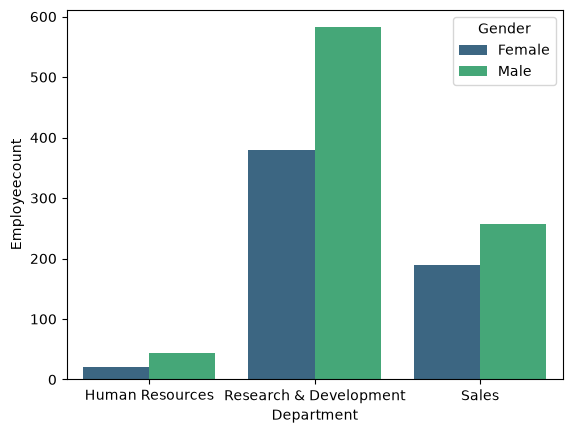

In [49]:
sb.barplot(data=grp_gender,x='Department',y='Employeecount',hue='Gender',palette='viridis')
plt.show()


In [50]:
data['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

#### Average salary hike (in percentage) given, categorized by Job Role.

In [51]:
grp_sal=data.groupby('JobRole')['PercentSalaryHike'].mean().round(1)

In [52]:
grp_sal

JobRole
Healthcare Representative    15.5
Human Resources              14.8
Laboratory Technician        15.0
Manager                      15.1
Manufacturing Director       15.6
Research Director            15.0
Research Scientist           15.4
Sales Executive              14.9
Sales Representative         15.7
Name: PercentSalaryHike, dtype: float64

#### All Job Roles have given an almost equal salary hike of 14-15% which indicates towards a standardised increment policy.

#### Salary hike distribution.

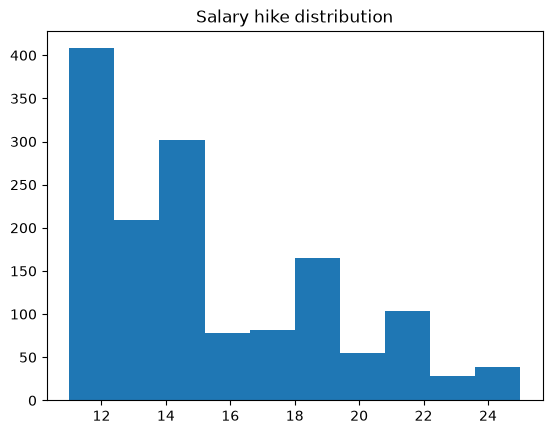

In [53]:
plt.hist(data['PercentSalaryHike'],bins=10)
plt.title('Salary hike distribution')
plt.show()

In [54]:
over_time=data['OverTime'].value_counts(normalize=True)*100

In [55]:
over_time.round(1)

OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64

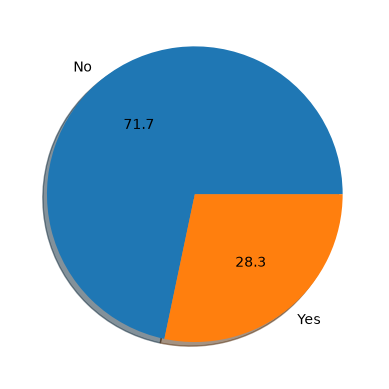

In [56]:
plt.pie(over_time.values,labels=over_time.index,autopct='%.1f',shadow=True)
plt.show()

#### A significant number of employees are seen as not working over-time. Thus, exhibiting a decent work-life balance.

In [57]:
data['WorkLifeBalance'].value_counts(normalize=True)*100

WorkLifeBalance
3    60.748299
2    23.401361
4    10.408163
1     5.442177
Name: proportion, dtype: float64

#### Around 71 % of employees have a decent work life balance. Which also co-relates to the 71% employees not working over-time.

In [58]:
overt_att=pd.crosstab(data['Attrition'],data['OverTime'],normalize='index')*100

In [59]:
overt_att.round(2)

OverTime,No,Yes
Attrition,,
No,76.56,23.44
Yes,46.41,53.59


#### 53.59 % of employees who worked over-time left the company, whereas, 76 % employees who did not work over time also did not leave the company.